# Løsningsforslag – øvingsoppgaver 1 – Lynkurs i statistikk
*Data Mining & Analytics – Samling 2, dag 1 (formiddag)*

Datasett: `tips` – 244 restaurantregninger (beløp, driks, kjønn på betaler, røyker, ukedag, tidspunkt, antall personer).
Bruk kodeeksemplene fra forelesningen (notebook 01–03) som utgangspunkt. Jobb gjerne i par.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(1)
tips = pd.read_csv("../Data/tips.csv")
tips["tip_pct"] = tips["tip"] / tips["total_bill"] * 100   
tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


### Oppgave 1 – Bli kjent med dataene
- a) Hvor mange rader og kolonner er det i datasettet? Mangler det verdier?
- b) Klassifiser hver variabel som *nominal, ordinal, diskret numerisk* eller *kontinuerlig*.
- c) Lag en tabell med gjennomsnitt, median og standardavvik for `total_bill`, `tip` og `tip_pct`.

In [3]:
print(tips.shape)
print(tips.isna().sum().sum(), "manglende verdier\n")
print(tips.dtypes)
tips[["total_bill", "tip", "tip_pct"]].agg(["mean", "median", "std"]).round(2)

(244, 8)
0 manglende verdier

total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
tip_pct       float64
dtype: object


,total_bill,tip,tip_pct
mean,19.79,3.00,16.08
median,17.80,2.90,15.48
std,8.90,1.38,6.11


In [4]:
tips["time"].unique()

array(['Dinner', 'Lunch'], dtype=object)

`total_bill`, `tip`, `tip_pct` er kontinuerlige. `size`er diskrete variabler. `sex`, `smoker`, `time`: nominale (binære) variabler. `day`: nominal/ordinale variabler.

Ingen manglende verdier. 

Snittet er høyere enn medianen for `total_bill` og `tip` betyr høyreskjev fordeling.

### Oppgave 2 – Fordeling og skjevhet
* a) Lag histogram og boksplott av `total_bill`.
* b) Hva skjer med skjevheten hvis du log-transformerer? Lag samme histogram for `np.log(total_bill)`.
* c) Er gjennomsnitt eller median best / mest representativ som den «typiske regningen»? Hvorfor?

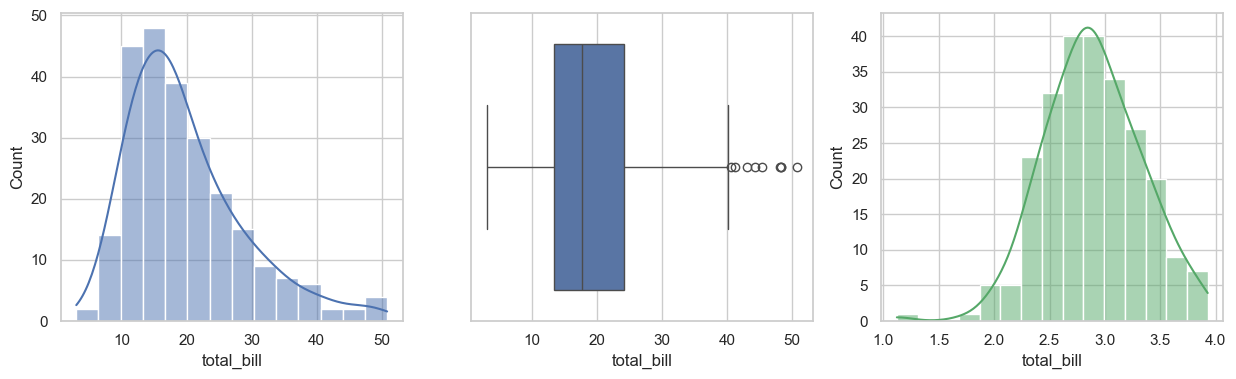

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(tips["total_bill"], kde=True, ax=ax[0])
sns.boxplot(x=tips["total_bill"], ax=ax[1])
sns.histplot(np.log(tips["total_bill"]), kde=True, ax=ax[2], color="C2")
plt.show()


Etter log-transformasjon er fordelingen mye mer symmetrisk.

Medianen er mer robust mot noen få veldig store regninger og er derfor mest representativ for en «typisk» regning.

### Oppgave 3 – Utvalg, standardfeil og konfidensintervall
Anta at de 244 regningene er hele populasjonen.

Trekk ett tilfeldig utvalg på n = 30. Beregn gjennomsnitt, standardfeil og 95 % konfidensintervall for gjennomsnittlig `total_bill`. Ligger den sanne populasjonsverdien i intervallet?


In [6]:
pop = tips["total_bill"].to_numpy()
mu = pop.mean()

u = rng.choice(pop, 30, replace=False)
se = u.std(ddof=1) / np.sqrt(30)
ki = stats.t.interval(0.95, 29, loc=u.mean(), scale=se)
print(f"x̄ = {u.mean():.2f}, SE = {se:.2f}, KI = {np.round(ki, 2)}, μ = {mu:.2f}")

x̄ = 18.43, SE = 1.58, KI = [15.2  21.65], μ = 19.79


Den sanne populasjonsverdien ligger i 95% CI-intervallet

### Oppgave 4 – Normalfordelingen
- a) Tilpass en normalfordeling til `tip_pct` (bruk gjennomsnitt og standardavvik). 
- b) Hva er P(tip_pct > 25) under normalfordelingen? Sammenlign med andelen i dataene.
- c) Lag QQ-plott og gjør Shapiro–Wilk. Er `tip_pct` normalfordelt? 

z(25%) = 1.46
Normal P(>25): 0.0721   Empirisk: 0.041


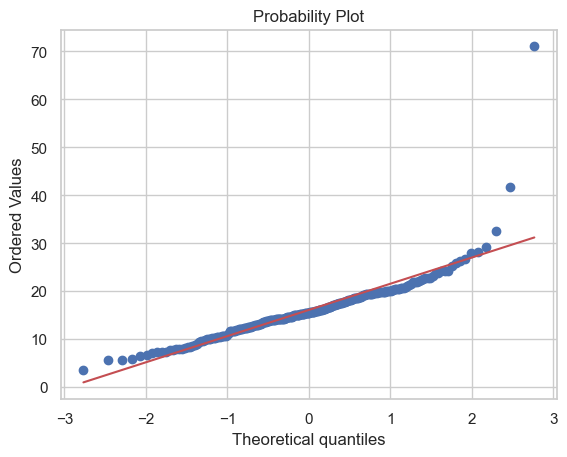

Shapiro p = 5.118350121040261e-17


In [7]:
m, s = tips["tip_pct"].mean(), tips["tip_pct"].std()
print("z(25%) =", round((25 - m) / s, 2))
print("Normal P(>25):", round(stats.norm.sf(25, m, s), 4), "  Empirisk:", round((tips["tip_pct"] > 25).mean(), 4))
stats.probplot(tips["tip_pct"], dist="norm", plot=plt.gca()); plt.show()
print("Shapiro p =", stats.shapiro(tips["tip_pct"]).pvalue)

z ≈ 1,46. Normalfordelingen gir P(> 25 %) ≈ 7 %, mens bare ≈ 4 % av dataene er over 25 %: noen få ekstreme driks (opp mot 70 %) gjør at standardavviket øker og gjør fordelingen høyreskjev med lang "hale". QQ-plottet avviker fra linja i øvre ende og Shapiro–Wilk avviser normalitet (p ≈ $10^{-17}$).

### Oppgave 5 – Korrelasjon
- a) Beregn Pearson-korrelasjon mellom `total_bill` og `tip`, og mellom `size` og `tip`. Lag scatterplott.
- b) Lag en korrelasjonsmatrise (heatmap) for de numeriske variablene.
- c) `size` og `tip` korrelerer. Men henger `size` også sammen med `total_bill`? Beregn den partielle korrelasjonen mellom `size` og `tip` når vi kontrollerer for `total_bill` (residualmetoden fra forelesningen). Hva er din/deres analyse/konklusjon basert på resultatet?

Korrelasjon mellom total_bill og tip: Pearson 0.68
Korrelasjon mellom size og tip: Pearson 0.49
Korrelasjon mellom size og total_bill: Pearson 0.60


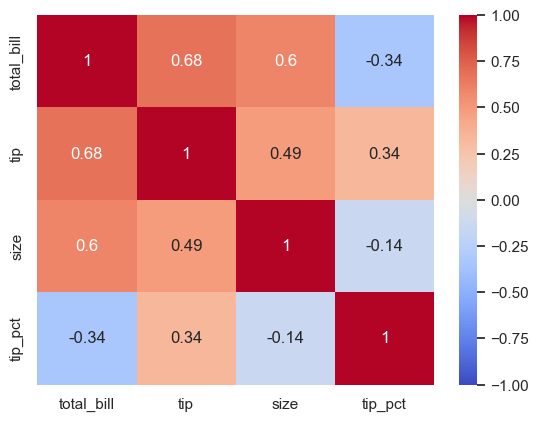

Partiell korrelasjon (size, tip | total_bill): 0.14


In [8]:
for a, b in [("total_bill", "tip"), ("size", "tip"), ("size", "total_bill")]:
    print(f"Korrelasjon mellom {a} og {b}: Pearson {stats.pearsonr(tips[a], tips[b])[0]:.2f}")

sns.heatmap(tips[["total_bill", "tip", "size", "tip_pct"]].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

def resid(y, x):
    return y - np.polyval(np.polyfit(x, y, 1), x)
r_part = np.corrcoef(resid(tips["size"], tips["total_bill"]), resid(tips["tip"], tips["total_bill"]))[0, 1]
print("Partiell korrelasjon (size, tip | total_bill):", round(r_part, 2))

**svar:**


`tip` korrelerer ganske sterkt med `total_bill` (r ≈ 0,68) og også med `size` (r ≈ 0,49), men `size` korrelerer også sterkt med `total_bill`. Kontrollert for regningen faller korrelasjonen mellom `size` og `tip` betydelig (≈ 0,1–0,2): mye av sammenhengen skyldes at større selskaper får høyere regning. Sammenhengen mellom driks i prosent og `total_bill` er derimot negativ.